In [1]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"

#211
#198
#124
#335

id = 198

scenario_response = requests.get(
    f"{URBAN_API}/scenarios/{id}"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_data = scenario_response.json()
project_id = scenario_data.get("project", {}).get("project_id")
if project_id is None:
    raise Exception("Project ID is missing in scenario data.")

territory_response = requests.get(
    f"{URBAN_API}/projects/{project_id}/territory"
        )

if territory_response.status_code != 200:
            raise Exception("Ошибка при получении геометрии территории")
        
territory_data = territory_response.json()
territory_geometry = territory_data["geometry"]
territory_feature = {
    'type': 'Feature',
    'geometry': territory_geometry,
    'properties': {}
}
polygon_gdf = gpd.GeoDataFrame.from_features([territory_feature], crs=4326)
polygon_gdf = polygon_gdf.to_crs(32636)


scenario_indicators_response = requests.get(
    f"{URBAN_API}/scenarios/{id}/indicators_values"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_indicators = scenario_indicators_response.json()

indicator_attributes = {
    indicator['indicator']['name_full']: indicator['value']
    for indicator in scenario_indicators
}

# Добавляем эти значения как колонки в polygon_gdf
for name, value in indicator_attributes.items():
    polygon_gdf[name] = value
    
polygon_gdf



,geometry,Численность населения,Население,Транспортное обеспечение,Экологическая ситуация,Обеспечение инженерной инфраструктурой,Социальное обеспечение,Средняя этажность,Коэффициент застройки,Коэффициент плотности застройки,...,Потенциал развития застройки общественно-деловой зоны,Потенциал развития среднеэтажной жилой застройки,Потенциал развития многоэтажной жилой застройки,Потенциал развития застройки рекреационной зоны,Потенциал развития застройки сельскохозяйственной зоны,Потенциал развития застройки зоны специального назначения,Потенциал развития застройки промышленной зоны,Потенциал развития застройки транспортной зоны,Срок рекультивации территории,Стоимость рекультивации территории
0,"POLYGON ((387861.999 6644712.938, 388202.551 6...",0.0,2.0,5.0,-2.66,5.0,4.0,2.0,0.2,0.05,...,2.0,3.0,1.0,4.0,3.0,3.0,4.0,4.0,6324.0,2.284321e+09


/Users/mvin/Code/Urbanomy/urbanomy/methods/investment_potential.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


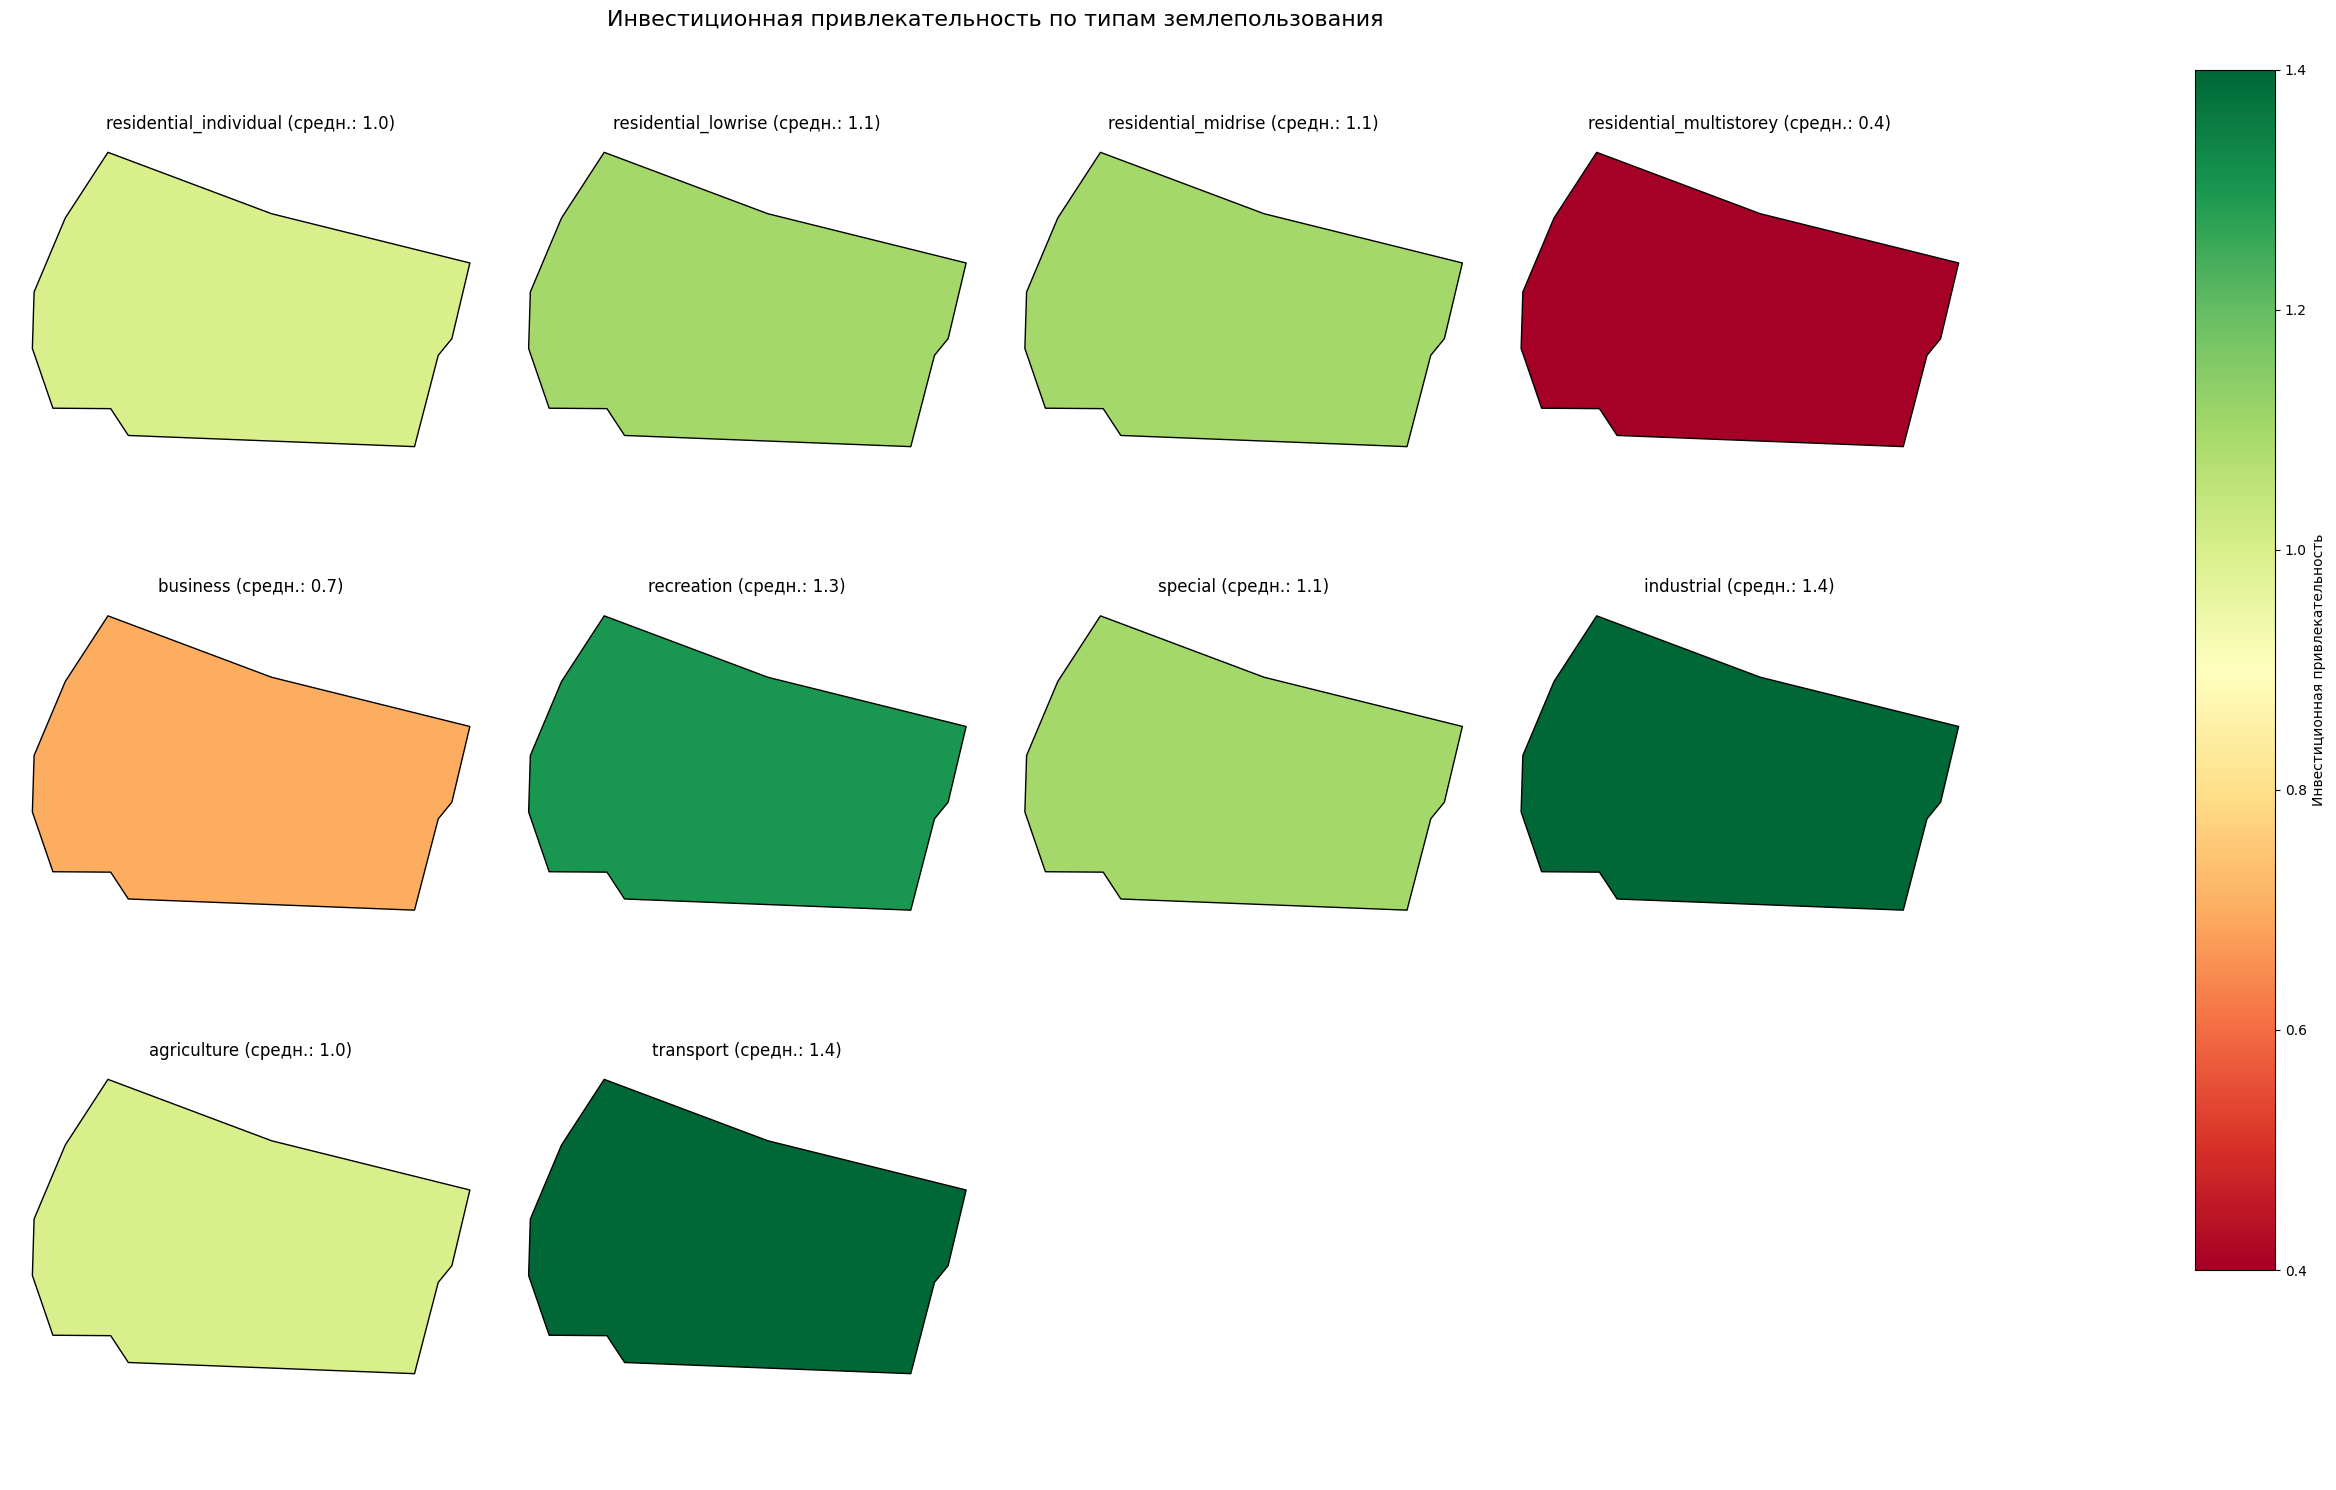

In [2]:
from urbanomy.methods.investment_potential import LandUseInvestmentAnalyzer

# custom_weights = {
#     'residential_individual': {
#         'Население': 1.0,
#         'default': 1.0
#     }
# }

analyzer = LandUseInvestmentAnalyzer(weights=None)
spatial_gdf = analyzer.compute_scores(polygon_gdf)
fig = analyzer.visualize_investment_maps(spatial_gdf)
plt.show()

In [3]:
import geopandas as gpd
import random
from shapely.geometry import Point
from shapely.ops import voronoi_diagram



# 2. Объединяем все геометрии (если их несколько) в одну
base_poly = spatial_gdf.geometry.unary_union

# 3. Список колонок ИП
ip_cols = [col for col in spatial_gdf.columns if col.startswith("ИП_")]

# 4. Генерируем точки-«семена» внутри base_poly
minx, miny, maxx, maxy = base_poly.bounds
random.seed(42)
seed_points = []
for ip in ip_cols:
    while True:
        x = random.uniform(minx, maxx)
        y = random.uniform(miny, maxy)
        p = Point(x, y)
        if p.within(base_poly):
            seed_points.append(p)
            break

points_gdf = gpd.GeoDataFrame(
    {"ip_type": ip_cols},
    geometry=seed_points,
    crs=spatial_gdf.crs
)

# 5. Строим Вороного
vor = voronoi_diagram(points_gdf.unary_union, envelope=base_poly)
vor_polys = list(vor.geoms) if hasattr(vor, "geoms") else list(vor)

# 6. Собираем зоны в GeoDataFrame
zones = []
for cell in vor_polys:
    for idx, row in points_gdf.iterrows():
        if row.geometry.within(cell):
            zones.append({
                "ip_type":  row["ip_type"],
                "ip_value": spatial_gdf.iloc[0][row["ip_type"]],
                "geometry": cell
            })
            break

zones_gdf = gpd.GeoDataFrame(zones, crs=spatial_gdf.crs)

# === НОВЫЙ ШАГ: обрезаем зоны по исходному полигонам spatial_gdf ===
zones_gdf = gpd.clip(zones_gdf, spatial_gdf)


# 8. Сохраняем результат
zones_gdf


/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_7759/3707091699.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  base_poly = spatial_gdf.geometry.unary_union
/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_7759/3707091699.py:34: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  vor = voronoi_diagram(points_gdf.unary_union, envelope=base_poly)


,ip_type,ip_value,geometry
7,ИП_residential_individual,1.0,"POLYGON ((389460.139 6643570.686, 390172.418 6..."
3,ИП_residential_multistorey,0.4,"POLYGON ((389429.389 6643590.914, 389460.139 6..."
6,ИП_industrial,1.4,"POLYGON ((390172.418 6643549.388, 390334.954 6..."
5,ИП_residential_lowrise,1.1,"POLYGON ((389090.462 6643932.194, 388423.317 6..."
2,ИП_agriculture,1.0,"POLYGON ((389125.366 6643950.229, 389429.389 6..."
1,ИП_business,0.7,"POLYGON ((389112.984 6644150.75, 389125.366 66..."
4,ИП_recreation,1.3,"POLYGON ((389429.389 6643590.914, 389125.366 6..."
9,ИП_transport,1.4,"POLYGON ((390334.954 6643620.983, 390237.235 6..."
8,ИП_residential_midrise,1.1,"POLYGON ((390237.235 6644109.31, 389610.404 66..."
0,ИП_special,1.1,"POLYGON ((389112.984 6644150.75, 387644.932 66..."


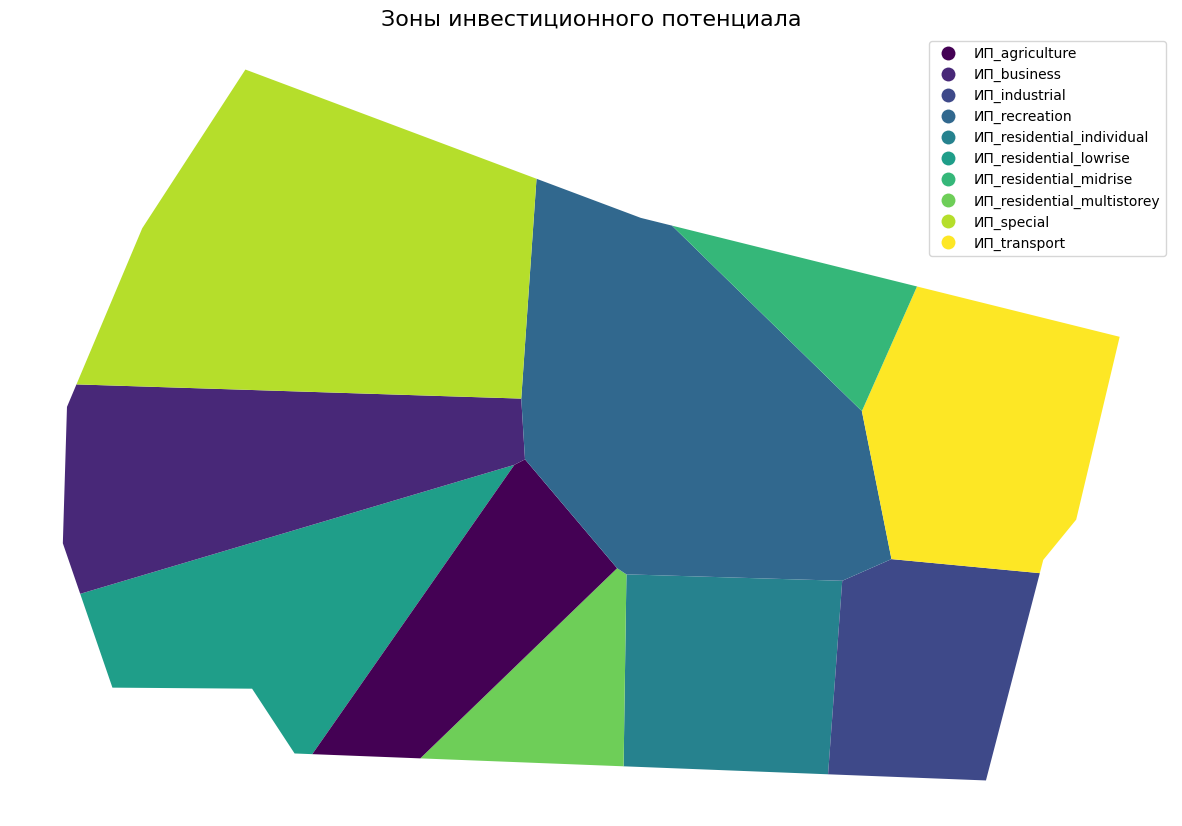

In [4]:
import matplotlib.pyplot as plt

# Создаём фигуру побольше
fig, ax = plt.subplots(figsize=(15, 15))

# Рисуем на нашей оси
zones_gdf.plot(
    column="ip_type",
    cmap="viridis",
    legend=True,
    ax=ax
)

# Убираем оси
ax.set_axis_off()

# Увеличиваем шрифт заголовка, если нужно
plt.title("Зоны инвестиционного потенциала", fontsize=16)

plt.show()


In [17]:
from __future__ import annotations
import math
from decimal import Decimal, ROUND_HALF_UP, getcontext
from typing import Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import geopandas as gpd


class InvestmentAttractivenessAnalyzer:
    """
    1) Генерирует cashflows по «грязным» бенчмаркам (density, cost_build, price_sale/rent_annual и т. п.)
       и считает для каждого профиля и всего проекта экономические метрики:
         • NPV (decimal с 2 знаками),
         • IRR, ROI, PP_years, EI (float, округлены до 4 знаков).
    2) Автоматически «подхватывает» spatial-метрики из столбцов ИП_<lu> или из пары (ip_type, ip_value)
       и синтезирует комбинированную привлекательность:
         INV_<lu> и сводный INV (float, округлены до 2 знаков).
    """
    DEFAULT_WEIGHTS      = {
        "residential_individual": (0.4, 0.6),
        "residential_lowrise"   : (0.4, 0.6),
        "residential_midrise"   : (0.5, 0.5),
        "residential_multistorey": (0.5, 0.5),
        "business"              : (0.3, 0.7),
        "recreation"            : (0.6, 0.4),
        "special"               : (0.3, 0.7),
        "industrial"            : (0.35,0.65),
        "agriculture"           : (0.6, 0.4),
        "transport"             : (0.35,0.65),
    }
    DEFAULT_ECON_METRIC   = "EI"
    DEFAULT_DISCOUNT_RATE = 0.12
    DEFAULT_AREA_COL      = "Площадь территории"
    DEFAULT_IP_TYPE       = "ip_type"
    DEFAULT_IP_VALUE      = "ip_value"

    def __init__(
        self,
        benchmarks: Dict[str, Dict[str, Any]],
        weights_dict: Dict[str, Tuple[float, float]] | None = None,
        econ_metric: str = DEFAULT_ECON_METRIC,
        discount_rate: float | None = None
    ):
        getcontext().prec = 28
        self.benchmarks    = benchmarks
        self.weights       = weights_dict or self.DEFAULT_WEIGHTS
        self.metric        = econ_metric.upper()
        self.discount_rate = discount_rate if discount_rate is not None else self.DEFAULT_DISCOUNT_RATE

    def fit_transform(self, gdf: gpd.GeoDataFrame) -> Tuple[gpd.GeoDataFrame, pd.DataFrame]:
        # 1) Авто-детект площади
        if self.DEFAULT_AREA_COL in gdf.columns:
            area_col = self.DEFAULT_AREA_COL
        else:
            area_col = "__area_tmp"
            gdf[area_col] = gdf.geometry.area

        # 2) Авто-детект spatial-формата
        if {self.DEFAULT_IP_TYPE, self.DEFAULT_IP_VALUE}.issubset(gdf.columns):
            ip_type_col, ip_value_col = self.DEFAULT_IP_TYPE, self.DEFAULT_IP_VALUE
        else:
            ip_type_col = ip_value_col = None

        # 3) Экономика
        gdf, summary = self._compute_economic(gdf, area_col, ip_type_col, ip_value_col)
        # 4) Синтез spatial+economic
        gdf = self._compute_spatial_economic_combined(gdf, ip_type_col, ip_value_col)
        # 5) Итоговый INV в summary
        summary = self._compute_summary_inv(summary)

        # 6) Удалим временную площадь
        if area_col == "__area_tmp":
            gdf.drop(columns=[area_col], inplace=True)

        return gdf, summary

    # -------------------------------------------------------------------------
    #  internal: cashflow builder + econ metrics
    # -------------------------------------------------------------------------
    def _make_cashflow(self, lu: str, land_area: float, b: Dict[str, Any]) -> List[float]:
        density = b["density"]
        gfa = land_area * density

        # capex
        land_cost = land_area * b.get("land_cost", 0)
        build_cost = gfa * b["cost_build"]
        years_build = b.get("construction_years", 2)
        capex_per_year = build_cost / years_build

        cf = [-land_cost - capex_per_year]
        for _ in range(1, years_build):
            cf.append(-capex_per_year)

        # opex + revenue
        opex = b.get("opex_rate", 0) * gfa
        if "price_sale" in b:
            yrs = b.get("sale_years", 3)
            rev_total = gfa * b["price_sale"]
            rev_p = rev_total / yrs
            for _ in range(yrs):
                cf.append(rev_p - opex)
        elif "rent_annual" in b:
            yrs = b.get("rent_years", 10)
            occ = b.get("occupancy", 0.9)
            rev_p = gfa * b["rent_annual"] * occ
            for _ in range(yrs):
                cf.append(rev_p - opex)
        else:
            raise ValueError(f"Profile '{lu}' needs price_sale or rent_annual")

        return cf

    @staticmethod
    def _npv(rate: float, cashflows: List[float]) -> float:
        return sum(cf / (1 + rate) ** t for t, cf in enumerate(cashflows))

    @staticmethod
    def _irr(cashflows: List[float], guess: float = 0.1, tol: float = 1e-6, max_iter: int = 100) -> float | None:
        rate = guess
        for _ in range(max_iter):
            npv = InvestmentAttractivenessAnalyzer._npv(rate, cashflows)
            deriv = sum(-t * cf / (1 + rate) ** (t + 1) for t, cf in enumerate(cashflows))
            if deriv == 0:
                break
            new = rate - npv / deriv
            if abs(new - rate) < tol:
                return new
            rate = new
        return None

    @staticmethod
    def _payback_period(rate: float, cashflows: List[float]) -> float | None:
        cum = 0.0
        for t, cf in enumerate(cashflows):
            cum += cf / (1 + rate) ** t
            if cum >= 0:
                prev = cum - cf / (1 + rate) ** t
                if cf == 0:
                    return float(t)
                return float(t) - (prev / (cf / (1 + rate) ** t))
        return None

    def _compute_economic(
        self,
        gdf: gpd.GeoDataFrame,
        area_col: str,
        ip_type_col: str | None,
        ip_value_col: str | None
    ) -> Tuple[gpd.GeoDataFrame, pd.DataFrame]:
        rows: List[Dict[str, Any]] = []
        for prof, b in self.benchmarks.items():
            ip_full = f"ИП_{prof}"
            # land area for profile
            if ip_type_col:
                land = gdf.loc[gdf[ip_type_col] == ip_full, area_col].sum()
            else:
                land = gdf[area_col].sum()

            cf_raw = self._make_cashflow(prof, land, b)
            rate  = b.get("discount_rate", self.discount_rate)

            raw_npv = self._npv(rate, cf_raw)
            npv = (Decimal(raw_npv)
                   .quantize(Decimal("0.01"), rounding=ROUND_HALF_UP)
                   if raw_npv is not None else None)

            irr = self._irr(cf_raw)
            roi = (sum(cf_raw[1:]) / -cf_raw[0] if cf_raw and cf_raw[0] < 0 else np.nan)
            pp  = self._payback_period(rate, cf_raw)

            # Economic Index
            ei = 0.0
            if raw_npv is not None:
                arg = -raw_npv / 1e8
                sig = 0.0 if arg > 700 else (1.0 if arg < -700 else 1.0 / (1 + math.exp(arg)))
                ei += 50 * sig
            if irr is not None:
                ei += 50 * max(0.0, irr - rate) / (0.3 - rate)
            ei = min(max(ei, 0.0), 100.0)

            # attach to gdf
            gdf[f"ECON_NPV_{prof}"] = npv
            gdf[f"ECON_IRR_{prof}"] = round(irr, 4) if irr is not None else np.nan
            gdf[f"ECON_ROI_{prof}"] = round(roi, 4)
            gdf[f"ECON_PP_{prof}"]  = round(pp, 4)  if pp is not None else np.nan
            gdf[f"ECON_EI_{prof}"]  = round(ei, 4)

            # base spatial attractiveness
            if ip_full in gdf.columns:
                inv_attr = gdf[ip_full].mean()
            elif ip_type_col and ip_value_col:
                inv_attr = gdf.loc[gdf[ip_type_col] == ip_full, ip_value_col].mean()
            else:
                inv_attr = np.nan

            rows.append({
                "profile": prof,
                "NPV": npv,
                "IRR": irr,
                "ROI": roi,
                "PP_years": pp,
                "EI": ei,
                "investment_attractiveness": inv_attr
            })

        summary = pd.DataFrame(rows).set_index("profile")

        # project-level metrics
        if len(gdf) > 1:
            all_cfs = [
                self._make_cashflow(
                    row.get(ip_type_col, "").replace("ИП_", ""),
                    row[area_col],
                    self.benchmarks[row.get(ip_type_col, "").replace("ИП_", "")]
                )
                for _, row in gdf.iterrows()
            ]
            max_len = max(len(x) for x in all_cfs)
            agg_cf  = [sum(cf[t] if t < len(cf) else 0.0 for cf in all_cfs) for t in range(max_len)]

            raw_npv = self._npv(self.discount_rate, agg_cf)
            proj_npv = (Decimal(raw_npv)
                        .quantize(Decimal("0.01"), rounding=ROUND_HALF_UP)
                        if raw_npv is not None else None)
            proj_irr = self._irr(agg_cf)
            proj_roi = (sum(agg_cf[1:]) / -agg_cf[0] if agg_cf and agg_cf[0] < 0 else np.nan)
            proj_pp  = self._payback_period(self.discount_rate, agg_cf)

            proj_ei = 0.0
            if raw_npv is not None:
                arg = -raw_npv / 1e8
                sig = 0.0 if arg > 700 else (1.0 if arg < -700 else 1.0 / (1 + math.exp(arg)))
                proj_ei += 50 * sig
            if proj_irr is not None:
                proj_ei += 50 * max(0.0, proj_irr - self.discount_rate) / (0.3 - self.discount_rate)
            proj_ei = min(max(proj_ei, 0.0), 100.0)

            inv_attr_proj = (gdf[self.DEFAULT_IP_VALUE].mean() if ip_value_col else np.nan)

            dfp = pd.DataFrame([{
                "profile": "project",
                "NPV": proj_npv,
                "IRR": proj_irr,
                "ROI": proj_roi,
                "PP_years": proj_pp,
                "EI": proj_ei,
                "investment_attractiveness": inv_attr_proj
            }]).set_index("profile")
            summary = pd.concat([summary, dfp])

        summary[["IRR", "ROI", "PP_years", "EI"]] = summary[["IRR", "ROI", "PP_years", "EI"]].round(2)
        return gdf, summary

    # -------------------------------------------------------------------------
    #  internal: spatial+economic synthesis
    # -------------------------------------------------------------------------
    def _compute_spatial_economic_combined(
        self,
        gdf: gpd.GeoDataFrame,
        ip_type_col: str | None,
        ip_value_col: str | None
    ) -> gpd.GeoDataFrame:
        spat_vals, econ_vals = [], []
        for lu in self.weights:
            ip_col = f"ИП_{lu}"
            # spatial raw
            if ip_col in gdf.columns:
                s = gdf[ip_col].astype(float)
            elif ip_type_col and ip_value_col:
                mask = gdf[ip_type_col] == ip_col
                tmp = pd.Series(0.0, index=gdf.index)
                tmp[mask] = gdf.loc[mask, ip_value_col].astype(float)
                s = tmp
            else:
                s = pd.Series(0.0, index=gdf.index)
            spat_vals += s.tolist()

            # econ raw
            econ_raw = gdf[f"ECON_{self.metric}_{lu}"]
            econ_vals += [float(v) if v is not None else np.nan for v in econ_raw]

        s_min, s_max = np.nanmin(spat_vals), np.nanmax(spat_vals)
        e_min, e_max = np.nanmin(econ_vals), np.nanmax(econ_vals)
        if self.metric in ("NPV", "ROI"):
            e_abs = max(abs(e_min), abs(e_max))
            e_min, e_max = -e_abs, e_abs

        for lu, (w_s, w_e) in self.weights.items():
            ip_col = f"ИП_{lu}"
            if ip_col in gdf.columns:
                s_raw = gdf[ip_col].astype(float)
            elif ip_type_col and ip_value_col:
                mask = gdf[ip_type_col] == ip_col
                s_raw = pd.Series(0.0, index=gdf.index)
                s_raw[mask] = gdf.loc[mask, ip_value_col].astype(float)
            else:
                s_raw = pd.Series(0.0, index=gdf.index)

            econ_raw = gdf[f"ECON_{self.metric}_{lu}"]
            e_raw = pd.Series([float(v) if v is not None else np.nan for v in econ_raw], index=gdf.index)

            s_norm = (100 * (s_raw - s_min) / (s_max - s_min)) if s_max > s_min else 0
            e_norm = (100 * (e_raw - e_min) / (e_max - e_min)) if e_max > e_min else 0

            gdf[f"INV_{lu}"] = (w_s * s_norm + w_e * e_norm).round(2)

        return gdf

    # -------------------------------------------------------------------------
    #  internal: summary INV
    # -------------------------------------------------------------------------
    def _compute_summary_inv(self, summary_df: pd.DataFrame) -> pd.DataFrame:
        df = summary_df.copy()
        s = pd.to_numeric(
            df["investment_attractiveness"].astype(str)
              .str.replace(r"[^0-9\.\-]+", "", regex=True),
            errors="coerce"
        )
        e = pd.to_numeric(
            df[self.metric].astype(str)
              .str.replace(r"[^0-9\.\-]+", "", regex=True),
            errors="coerce"
        )

        s_min, s_max = s.min(), s.max()
        e_min, e_max = e.min(), e.max()
        if self.metric in ("NPV", "ROI"):
            e_abs = max(abs(e_min), abs(e_max))
            e_min, e_max = -e_abs, e_abs

        s_norm = (100 * (s - s_min) / (s_max - s_min)) if s_max > s_min else 0
        e_norm = (100 * (e - e_min) / (e_max - e_min)) if e_max > e_min else 0

        ws = pd.Series({lu: w_s for lu, (w_s, _) in self.weights.items()})
        we = pd.Series({lu: w_e for lu, (_, w_e) in self.weights.items()})
        avg_ws, avg_we = ws.mean(), we.mean()
        ws["project"], we["project"] = avg_ws, avg_we

        df["INV"] = (ws * s_norm + we * e_norm).round(2)
        return df


In [12]:
benchmarks_demo = {
    "residential_individual": {
        "density": 0.25,
        "land_cost": 1500,
        "cost_build": 48_000,
        "price_sale": 92_000,
        "construction_years": 2,
        "sale_years": 3,
        "opex_rate": 800,
        "discount_rate": 0.12
    },
    "residential_lowrise": {
        "density": 0.5,
        "land_cost": 1800,
        "cost_build": 50_000,
        "price_sale": 95_000,
        "construction_years": 2,
        "sale_years": 3,
        "opex_rate": 900
    },
    "residential_midrise": {
        "density": 1.5,
        "land_cost": 2500,
        "cost_build": 55_000,
        "price_sale": 105_000,
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 1_200
    },
    "residential_multistorey": {
        "density": 3.0,
        "land_cost": 3000,
        "cost_build": 62_000,
        "price_sale": 120_000,
        "construction_years": 4,
        "sale_years": 5,
        "opex_rate": 1_500
    },
    "business": {
        "density": 2.0,
        "land_cost": 2800,
        "cost_build": 55_000,
        "rent_annual": 14_000,
        "rent_years": 12,
        "occupancy": 0.85,
        "construction_years": 3,
        "opex_rate": 1_300
    },
    "recreation": {
        "density": 0.2,
        "land_cost": 1000,
        "cost_build": 40_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "occupancy": 0.7,
        "construction_years": 2,
        "opex_rate": 1_000
    },
    "special": {
        "density": 1.0,
        "land_cost": 1200,
        "cost_build": 45_000,
        "rent_annual": 8_000,
        "rent_years": 15,
        "occupancy": 0.8,
        "construction_years": 3,
        "opex_rate": 1_500
    },
    "industrial": {
        "density": 1.0,
        "land_cost": 900,
        "cost_build": 38_000,
        "rent_annual": 5_800,
        "rent_years": 12,
        "occupancy": 0.9,
        "construction_years": 2,
        "opex_rate": 700
    },
    "agriculture": {
        "density": 0.1,
        "land_cost": 300,
        "cost_build": 25_000,
        "rent_annual": 2_500,
        "rent_years": 15,
        "occupancy": 0.95,
        "construction_years": 1,
        "opex_rate": 300
    },
    "transport": {
        "density": 1.2,
        "land_cost": 1_100,
        "cost_build": 32_000,
        "rent_annual": 4_200,
        "rent_years": 15,
        "occupancy": 0.88,
        "construction_years": 3,
        "opex_rate": 600
    }
}

In [18]:
analyzer = InvestmentAttractivenessAnalyzer(
    benchmarks_demo,
    # econ_metric="EI"  # или "IRR"/"ROI"/"NPV"
)
gdf_enriched, summary_df = analyzer.fit_transform(zones_gdf)
summary_df

/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_7759/110151140.py:251: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary = pd.concat([summary, dfp])


,NPV,IRR,ROI,PP_years,EI,investment_attractiveness,INV
profile,,,,,,,
residential_individual,1394131023.18,0.22,2.19,4.34,78.67,1.00,79.87
residential_lowrise,4437204500.27,0.24,2.35,4.23,84.48,1.10,88.00
residential_midrise,2678973065.04,0.18,3.18,6.24,66.06,1.10,74.10
residential_multistorey,2748942668.07,0.14,4.00,8.56,55.08,0.40,32.60
business,2237508700.13,0.13,4.59,14.25,51.57,0.70,51.73
recreation,-4640501513.22,0.02,1.33,NaN,0.00,1.30,54.00
special,-17402909540.60,0.06,2.69,NaN,0.00,1.10,21.00
industrial,-4853344624.66,0.05,1.77,NaN,0.00,1.40,35.00
agriculture,-556140242.00,0.01,1.11,NaN,0.19,1.00,36.09
